In [1]:
# Seasonal Agriculture Performance Analysis

## Project Objective

# This project analyzes agricultural performance across different seasons,
# crops, geographical regions and farming conditions.

# The analysis focuses on:

# - Seasonal variations in crop yield
# - Agricultural profitability
# - Water usage and water efficiency
# - Crop-wise performance
# - Irrigation methods
# - Environmental conditions
# - Relationships between agricultural variables
# - Statistical differences across seasons

# The objective is to identify meaningful patterns and generate
# evidence-based insights for seasonal agricultural planning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

In [ ]:
import sys
import os

import sys
import os

src_path = os.path.abspath("../src")

if src_path not in sys.path:
    sys.path.insert(0, src_path)

from data_cleaning import (
    check_missing_values,
    check_duplicates,
    validate_numeric_values,
    fill_missing_values,
    create_performance_metrics
)

from analysis import (
    seasonal_summary,
    crop_summary,
    irrigation_summary,
    crop_season_profit,
    economic_comparison
)

from statistical_analysis import (
    seasonal_profit_kruskal_test,
    pairwise_season_tests,
    spearman_correlations
)

from visualizations import (
    seasonal_profit_plot,
    seasonal_water_efficiency_plot,
    crop_profit_plot,
    crop_season_heatmap,
    correlation_heatmap
)

In [ ]:
file_path = "../data/seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset loaded successfully.
Rows    : 4000
Columns : 28


In [ ]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [ ]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [ ]:
df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
for number, column in enumerate(df.columns, start=1):
    print(f"{number}. {column}")

Dataset Shape: (4000, 28)

Column Names:
1. Farm_ID
2. State
3. District
4. Crop
5. Season
6. Farm_Area_Hectares
7. Rainfall_mm
8. Avg_Temperature_C
9. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"3,960.00",26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [ ]:
print("Number of numerical columns:", len(numeric_columns))
print("Number of categorical columns:", len(categorical_columns))

Number of numerical columns: 22
Number of categorical columns: 6


In [ ]:
for column in categorical_columns:
    print(f"\n{'=' * 50}")
    print(column)
    print(f"{'=' * 50}")
    print(df[column].value_counts())


Farm_ID
Farm_ID
SF10001    1
SF10002    1
SF10003    1
SF10004    1
SF10005    1
          ..
SF13996    1
SF13997    1
SF13998    1
SF13999    1
SF14000    1
Name: count, Length: 4000, dtype: int64

State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count,

In [ ]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df)) * 100
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values(
    "Missing Values",
    ascending=False
)

missing_summary

,Missing Values,Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


In [ ]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [ ]:
print("Total records:", len(df))
print("Unique Farm IDs:", df["Farm_ID"].nunique())

Total records: 4000
Unique Farm IDs: 4000


In [ ]:
validation_checks = {
    "Negative farm area": (df["Farm_Area_Hectares"] <= 0).sum(),
    "Negative rainfall": (df["Rainfall_mm"] < 0).sum(),
    "Negative yield": (df["Yield_Tonnes_Ha"] < 0).sum(),
    "Negative production": (df["Production_Tonnes"] < 0).sum(),
    "Negative water usage": (df["Water_Used_m3"] < 0).sum(),
    "Invalid soil pH": (
        (df["Soil_pH"] < 0) |
        (df["Soil_pH"] > 14)
    ).sum()
}

validation_results = pd.DataFrame(
    validation_checks.items(),
    columns=["Validation Check", "Count"]
)

validation_results

,Validation Check,Count
0,Negative farm area,0
1,Negative rainfall,0
2,Negative yield,0
3,Negative production,0
4,Negative water usage,0
5,Invalid soil pH,0


In [ ]:
columns_to_impute = [
    "Rainfall_mm",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]

for column in columns_to_impute:
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)

print("Missing numerical values handled using median imputation.")

Missing numerical values handled using median imputation.


In [ ]:
print("Total missing values after cleaning:",
      df.isnull().sum().sum())

Total missing values after cleaning: 0


In [ ]:
cleaning_check = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Data Type": df.dtypes.astype(str)
})

cleaning_check

,Missing Values,Data Type
Farm_ID,0,object
State,0,object
District,0,object
Crop,0,object
Season,0,object
Farm_Area_Hectares,0,float64
Rainfall_mm,0,float64
Avg_Temperature_C,0,float64
Humidity_pct,0,float64
Sunlight_Hours_Day,0,float64


In [ ]:
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isnull().sum().sum())

Duplicate rows: 0
Total missing values: 0


In [ ]:
# ## Feature Engineering

# Total profit depends partly on farm size. Therefore, comparing total profit
# alone may not provide a fair comparison between farms of different areas.

# To make the economic performance comparable, profit, revenue and cost are
# normalized by farm area.

In [ ]:
# Create normalized economic performance metrics

df["Profit_per_Hectare_INR"] = (
    df["Profit_INR"] / df["Farm_Area_Hectares"]
)

df["Revenue_per_Hectare_INR"] = (
    df["Revenue_INR"] / df["Farm_Area_Hectares"]
)

df["Cost_per_Hectare_INR"] = (
    df["Total_Cost_INR"] / df["Farm_Area_Hectares"]
)

df["Profit_Margin_pct"] = (
    df["Profit_INR"] / df["Revenue_INR"]
) * 100

print("New performance metrics created.")

New performance metrics created.


In [ ]:
df[
    [
        "Farm_Area_Hectares",
        "Profit_INR",
        "Profit_per_Hectare_INR",
        "Revenue_per_Hectare_INR",
        "Cost_per_Hectare_INR",
        "Profit_Margin_pct"
    ]
].head(10)

,Farm_Area_Hectares,Profit_INR,Profit_per_Hectare_INR,Revenue_per_Hectare_INR,Cost_per_Hectare_INR,Profit_Margin_pct
0,0.53,-11852,"-22,362.26","58,132.08","80,494.34",-38.47
1,6.53,-451950,"-69,211.33","6,186.98","75,398.32","-1,118.66"
2,4.86,-124744,"-25,667.49","39,190.53","64,858.02",-65.49
3,4.50,-95704,"-21,267.56","44,608.89","65,876.44",-47.68
4,4.21,-144352,"-34,287.89","45,987.41","80,275.30",-74.56
5,5.46,-32763,"-6,000.55","49,371.79","55,372.34",-12.15
6,8.13,-41239,"-5,072.45","58,069.13","63,141.57",-8.74
7,5.34,5065,948.50,"82,633.90","81,685.39",1.15
8,6.98,230705,"33,052.29","108,285.67","75,233.38",30.52
9,13.69,1954835,"142,792.91","216,136.38","73,343.46",66.07


In [ ]:
print(
    "Missing profit/ha:",
    df["Profit_per_Hectare_INR"].isnull().sum()
)

print(
    "Missing profit margin:",
    df["Profit_Margin_pct"].isnull().sum()
)

print(
    "Infinite profit/ha:",
    np.isinf(df["Profit_per_Hectare_INR"]).sum()
)

print(
    "Infinite profit margin:",
    np.isinf(df["Profit_Margin_pct"]).sum()
)

Missing profit/ha: 0
Missing profit margin: 0
Infinite profit/ha: 0
Infinite profit margin: 0


In [ ]:
overall_summary = pd.Series({
    "Total Farms": len(df),
    "Total Agricultural Area (ha)": df["Farm_Area_Hectares"].sum(),
    "Average Yield (tonnes/ha)": df["Yield_Tonnes_Ha"].mean(),
    "Average Profit (INR)": df["Profit_INR"].mean(),
    "Average Profit per Hectare (INR)": df["Profit_per_Hectare_INR"].mean(),
    "Average Water Used (m3)": df["Water_Used_m3"].mean(),
    "Average Water Efficiency": df["Water_Efficiency_t_per_1000m3"].mean()
})

overall_summary

Total Farms                          4,000.00
Total Agricultural Area (ha)        31,553.06
Average Yield (tonnes/ha)                5.24
Average Profit (INR)               111,556.46
Average Profit per Hectare (INR)    13,555.02
Average Water Used (m3)              6,045.57
Average Water Efficiency                 5.39
dtype: float64

In [ ]:
# ## Exploratory Data Analysis

# The first stage of exploratory analysis examines how observations are
# distributed across seasons, crops, regions and irrigation methods.

In [ ]:
season_distribution = (
    df["Season"]
    .value_counts()
    .rename_axis("Season")
    .reset_index(name="Number_of_Farms")
)

season_distribution

,Season,Number_of_Farms
0,Kharif,1779
1,Rabi,1627
2,Zaid,594


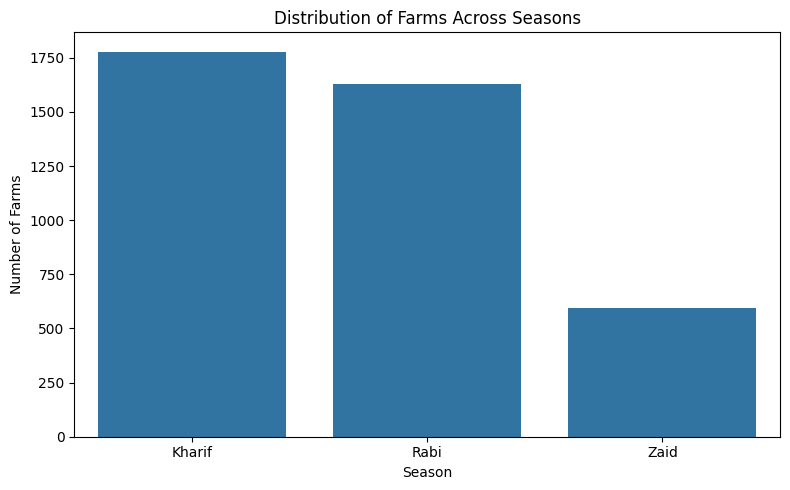

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=season_distribution,
    x="Season",
    y="Number_of_Farms"
)

plt.title("Distribution of Farms Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Farms")

plt.tight_layout()
plt.show()

In [ ]:
crop_distribution = (
    df["Crop"]
    .value_counts()
    .rename_axis("Crop")
    .reset_index(name="Number_of_Farms")
)

crop_distribution

,Crop,Number_of_Farms
0,Rice,690
1,Wheat,614
2,Maize,551
3,Cotton,508
4,Pulses,496
5,Groundnut,424
6,Chilli,412
7,Sugarcane,305


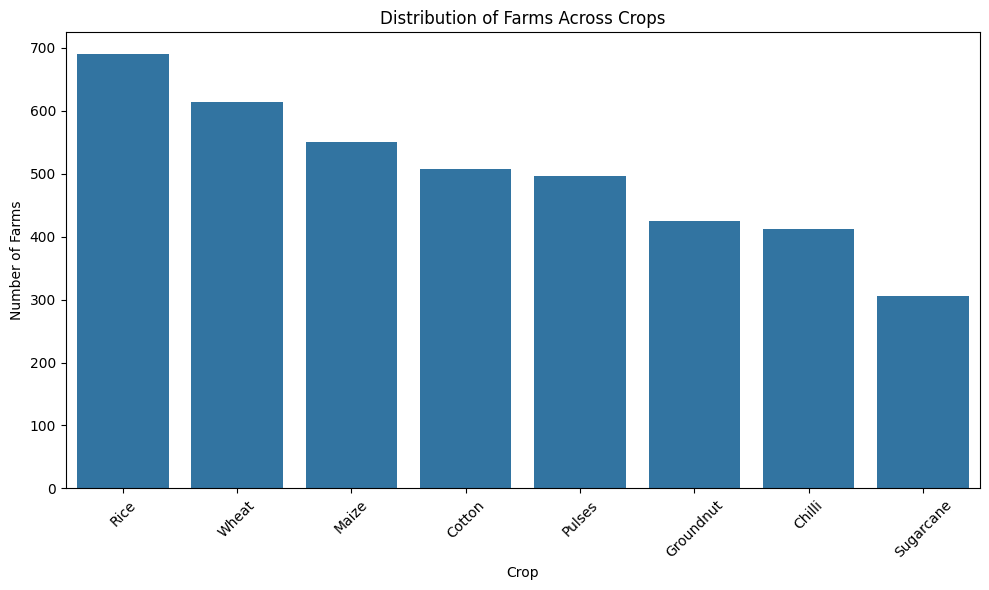

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=crop_distribution,
    x="Crop",
    y="Number_of_Farms"
)

plt.xticks(rotation=45)

plt.title("Distribution of Farms Across Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Farms")

plt.tight_layout()
plt.show()

In [ ]:
season_crop_count = pd.crosstab(
    df["Crop"],
    df["Season"]
)

season_crop_count

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


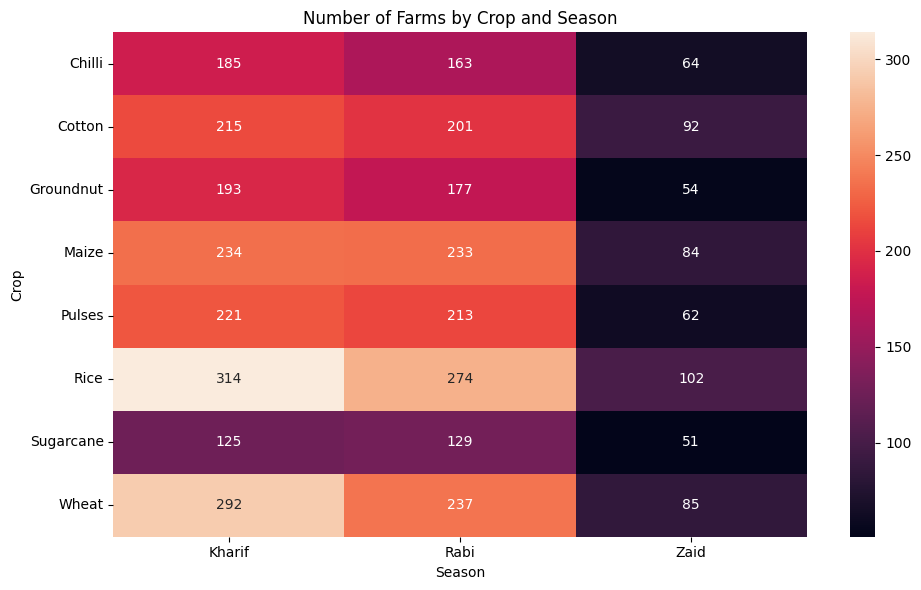

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    season_crop_count,
    annot=True,
    fmt="d"
)

plt.title("Number of Farms by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

In [ ]:
# ## Seasonal Performance Analysis

# The main objective is to determine whether agricultural performance changes
# across seasons. Yield, profitability, water consumption and water efficiency
# are compared using season-level averages.

In [ ]:
season_summary = df.groupby("Season").agg(
    Number_of_Farms=("Farm_ID", "count"),
    Average_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Average_Profit_INR=("Profit_INR", "mean"),
    Average_Profit_per_Hectare_INR=("Profit_per_Hectare_INR", "mean"),
    Average_Water_Used_m3=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Disease_Risk_pct=("Disease_Pest_Risk_pct", "mean")
).round(2)

season_summary

,Number_of_Farms,Average_Yield_Tonnes_Ha,Average_Profit_INR,Average_Profit_per_Hectare_INR,Average_Water_Used_m3,Average_Water_Efficiency,Average_Disease_Risk_pct
Season,,,,,,,
Kharif,1779,5.63,"178,914.65","21,881.81","6,102.20",5.89,54.47
Rabi,1627,5.04,"87,689.47","10,361.68","5,846.99",5.19,40.48
Zaid,594,4.64,"-24,804.82","-2,636.52","6,419.89",4.41,38.22


In [ ]:
best_yield_season = (
    season_summary["Average_Yield_Tonnes_Ha"].idxmax()
)

best_profit_season = (
    season_summary["Average_Profit_per_Hectare_INR"].idxmax()
)

highest_water_use_season = (
    season_summary["Average_Water_Used_m3"].idxmax()
)

best_water_efficiency_season = (
    season_summary["Average_Water_Efficiency"].idxmax()
)

print("Highest average yield:", best_yield_season)
print("Highest average profit/ha:", best_profit_season)
print("Highest average water usage:", highest_water_use_season)
print("Highest water efficiency:", best_water_efficiency_season)

Highest average yield: Kharif
Highest average profit/ha: Kharif
Highest average water usage: Zaid
Highest water efficiency: Kharif


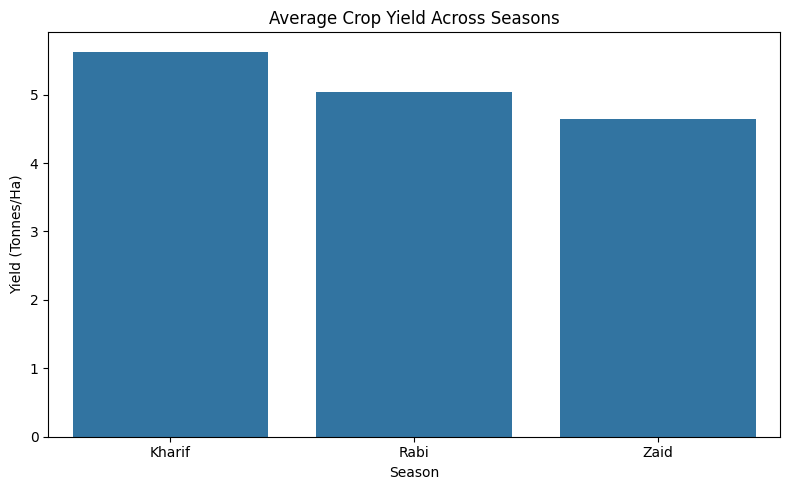

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    estimator="mean",
    errorbar=None
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

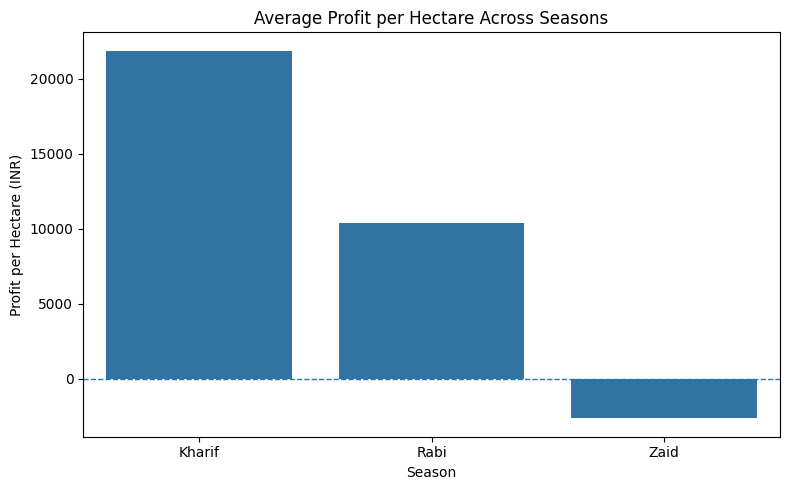

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_per_Hectare_INR",
    estimator="mean",
    errorbar=None
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("Average Profit per Hectare Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit per Hectare (INR)")

plt.tight_layout()
plt.show()

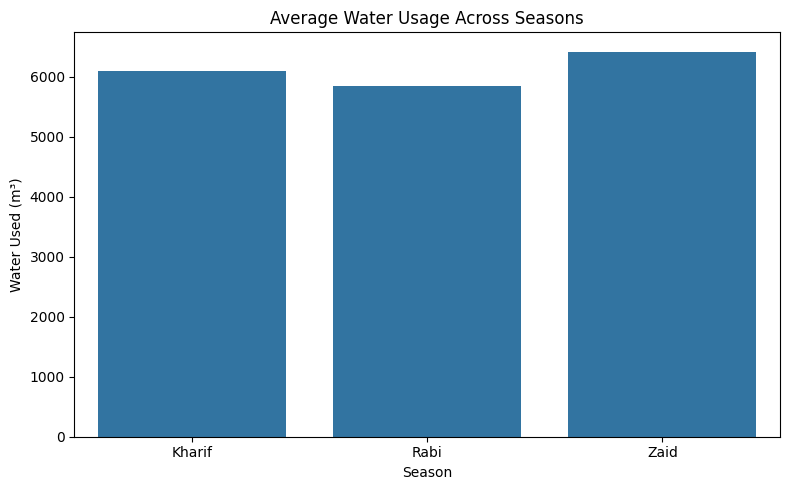

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Water_Used_m3",
    estimator="mean",
    errorbar=None
)

plt.title("Average Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")

plt.tight_layout()
plt.show()

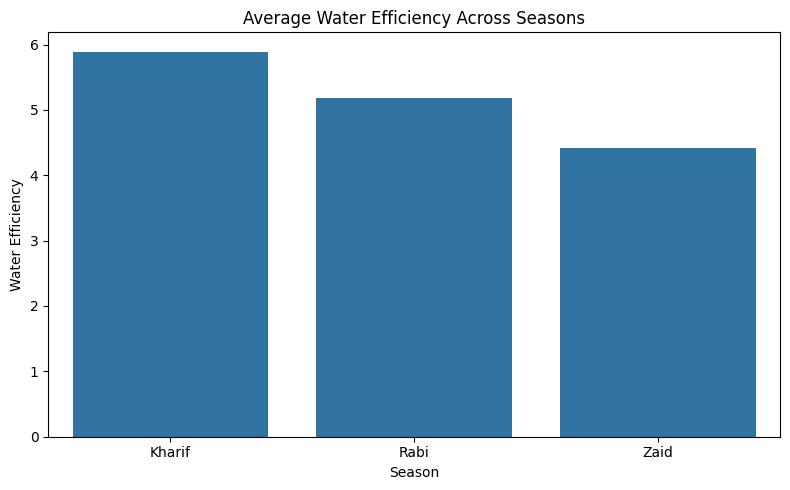

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Water_Efficiency_t_per_1000m3",
    estimator="mean",
    errorbar=None
)

plt.title("Average Water Efficiency Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Efficiency")

plt.tight_layout()
plt.show()

In [ ]:
# ## Crop-wise Performance Analysis

# Seasonal performance can also depend on the type of crop being cultivated.
# Therefore, crop-wise yield, profitability, water efficiency and disease risk
# are analyzed to identify crops with different performance characteristics. 

In [ ]:
crop_summary = df.groupby("Crop").agg(
    Number_of_Farms=("Farm_ID", "count"),
    Average_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Average_Profit_per_Hectare_INR=("Profit_per_Hectare_INR", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Disease_Risk_pct=("Disease_Pest_Risk_pct", "mean")
).sort_values(
    "Average_Profit_per_Hectare_INR",
    ascending=False
).round(2)

crop_summary

,Number_of_Farms,Average_Yield_Tonnes_Ha,Average_Profit_per_Hectare_INR,Average_Water_Efficiency,Average_Disease_Risk_pct
Crop,,,,,
Sugarcane,305,46.64,"97,169.92",30.48,45.40
Chilli,412,1.54,"92,123.09",2.95,46.06
Cotton,508,1.23,"16,354.22",1.94,45.97
Groundnut,424,1.32,"7,443.69",3.15,46.29
Pulses,496,0.92,-693.36,2.90,46.57
Maize,551,2.71,"-10,203.08",5.60,45.54
Rice,690,2.43,"-13,137.46",1.95,46.50
Wheat,614,2.11,"-15,968.82",4.63,47.85


In [ ]:
best_crop_profit = crop_summary[
    "Average_Profit_per_Hectare_INR"
].idxmax()

best_crop_yield = crop_summary[
    "Average_Yield_Tonnes_Ha"
].idxmax()

best_crop_water = crop_summary[
    "Average_Water_Efficiency"
].idxmax()

print("Highest average profit/ha:", best_crop_profit)
print("Highest average yield:", best_crop_yield)
print("Highest water efficiency:", best_crop_water)

Highest average profit/ha: Sugarcane
Highest average yield: Sugarcane
Highest water efficiency: Sugarcane


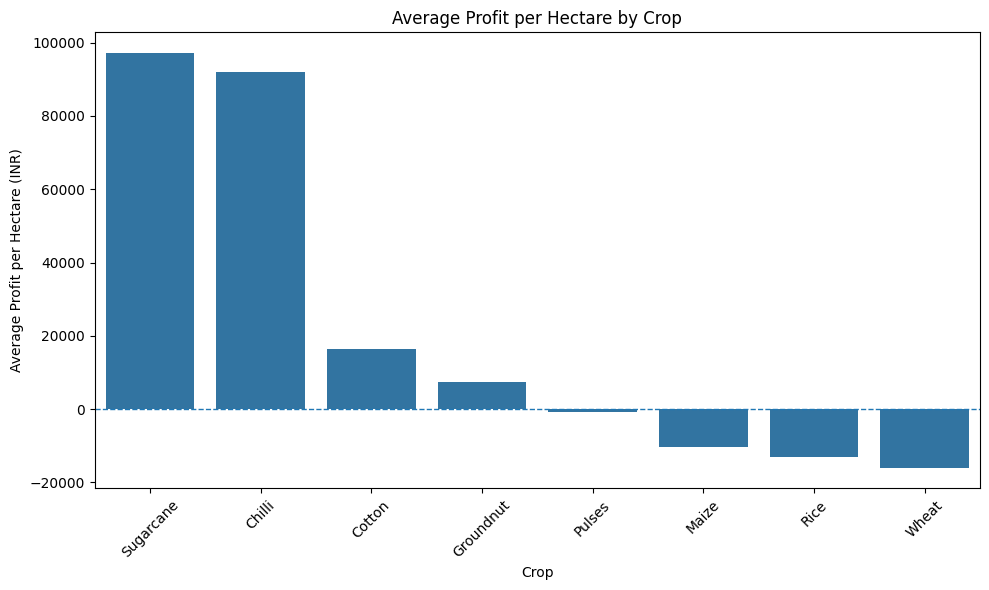

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=crop_summary.reset_index(),
    x="Crop",
    y="Average_Profit_per_Hectare_INR"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xticks(rotation=45)

plt.title("Average Profit per Hectare by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit per Hectare (INR)")

plt.tight_layout()
plt.show()

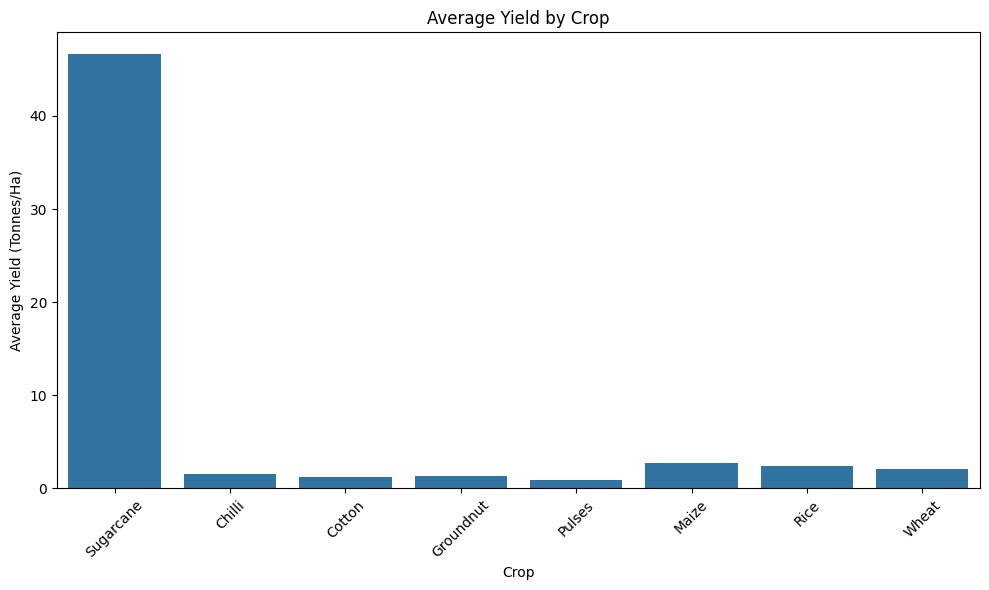

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=crop_summary.reset_index(),
    x="Crop",
    y="Average_Yield_Tonnes_Ha"
)

plt.xticks(rotation=45)

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

In [ ]:
crop_season_profit = df.pivot_table(
    values="Profit_per_Hectare_INR",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

crop_season_profit.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,"111,812.03","85,696.18","51,578.32"
Cotton,"27,343.10","13,517.73","-3,129.21"
Groundnut,"16,870.94","1,927.18","-8,168.15"
Maize,"-4,968.28","-11,776.24","-20,422.12"
Pulses,"7,043.55","-3,419.73","-18,905.27"
Rice,"-7,986.98","-14,524.71","-25,266.34"
Sugarcane,"120,564.29","86,013.50","68,049.98"
Wheat,"-13,181.57","-16,083.98","-25,222.79"


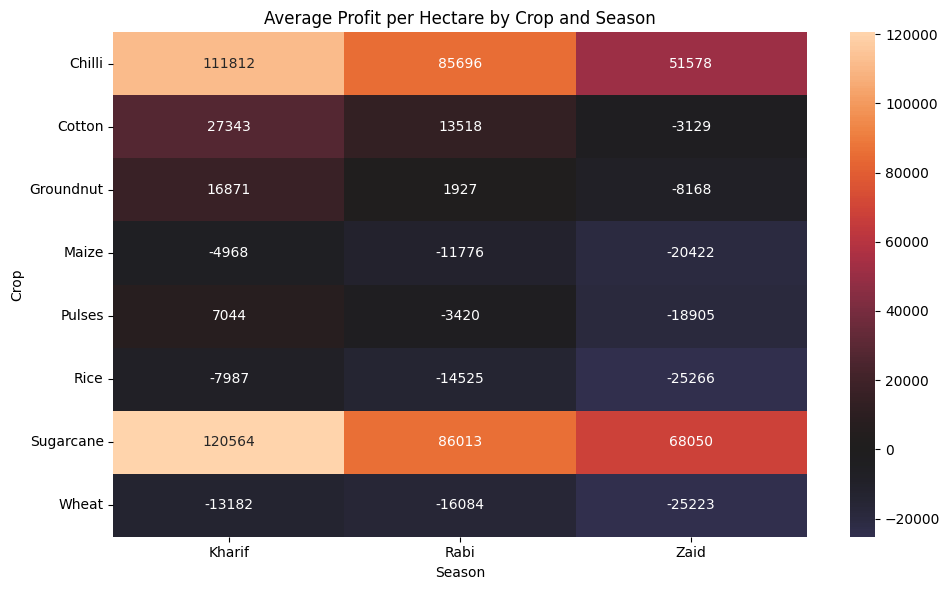

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_season_profit,
    annot=True,
    fmt=".0f",
    center=0
)

plt.title("Average Profit per Hectare by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

In [ ]:
crop_season_yield = df.pivot_table(
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

crop_season_yield.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


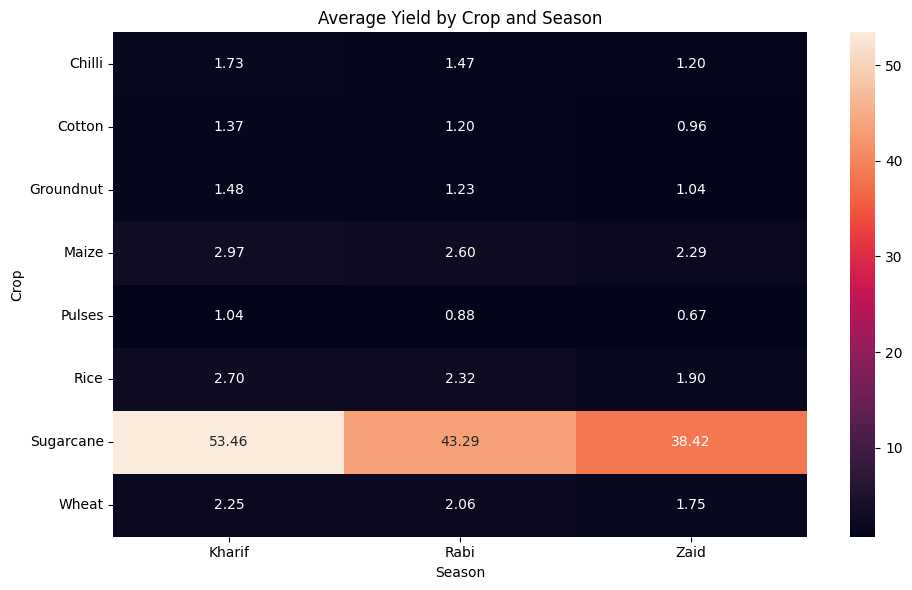

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f"
)

plt.title("Average Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

In [ ]:
# ## Irrigation Analysis

# Irrigation is an important resource-related factor in agricultural
# performance. The different irrigation methods are compared using yield,
# profitability, water consumption and water efficiency.

In [ ]:
irrigation_summary = df.groupby("Irrigation_Method").agg(
    Number_of_Farms=("Farm_ID", "count"),
    Average_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Average_Profit_per_Hectare_INR=("Profit_per_Hectare_INR", "mean"),
    Average_Water_Used_m3=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values(
    "Average_Profit_per_Hectare_INR",
    ascending=False
).round(2)

irrigation_summary

,Number_of_Farms,Average_Yield_Tonnes_Ha,Average_Profit_per_Hectare_INR,Average_Water_Used_m3,Average_Water_Efficiency
Irrigation_Method,,,,,
Drip,915,6.58,"25,606.90","5,918.75",6.27
Sprinkler,734,5.16,"12,635.01","6,208.26",4.67
Rainfed,1041,4.60,"9,481.02","3,549.55",7.56
Flood,1310,4.86,"8,890.04","8,026.47",3.44


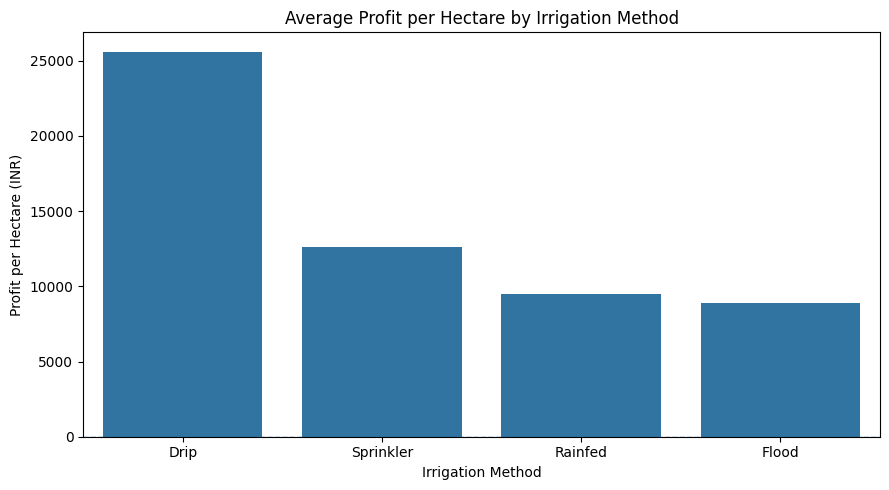

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=irrigation_summary.reset_index(),
    x="Irrigation_Method",
    y="Average_Profit_per_Hectare_INR"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("Average Profit per Hectare by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Profit per Hectare (INR)")

plt.tight_layout()
plt.show()

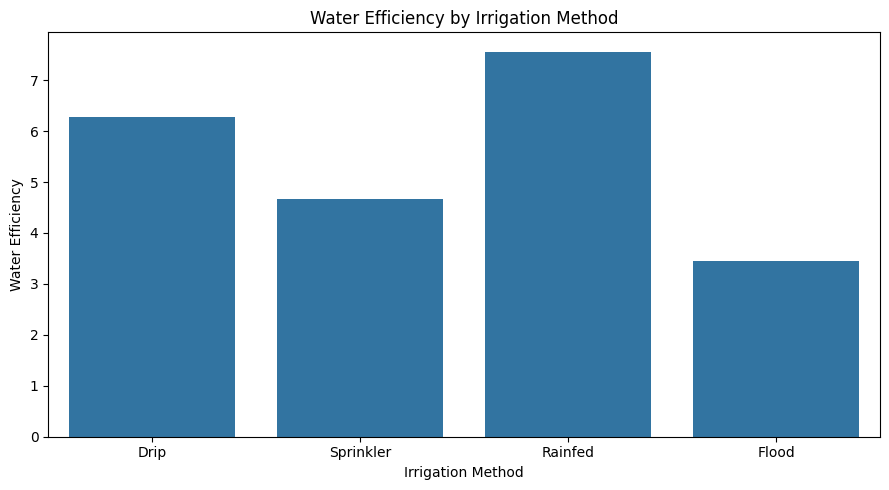

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=irrigation_summary.reset_index(),
    x="Irrigation_Method",
    y="Average_Water_Efficiency"
)

plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency")

plt.tight_layout()
plt.show()

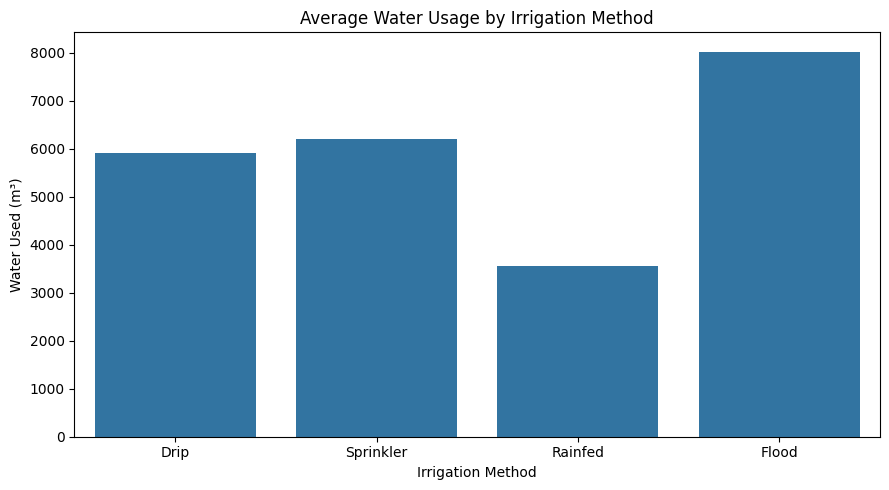

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=irrigation_summary.reset_index(),
    x="Irrigation_Method",
    y="Average_Water_Used_m3"
)

plt.title("Average Water Usage by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Used (m³)")

plt.tight_layout()
plt.show()

In [ ]:
# ## Environmental Conditions and Agricultural Performance

# Environmental conditions such as rainfall, temperature, humidity and soil
# conditions may be associated with agricultural outcomes. Relationships
# between these variables and crop yield are therefore examined.

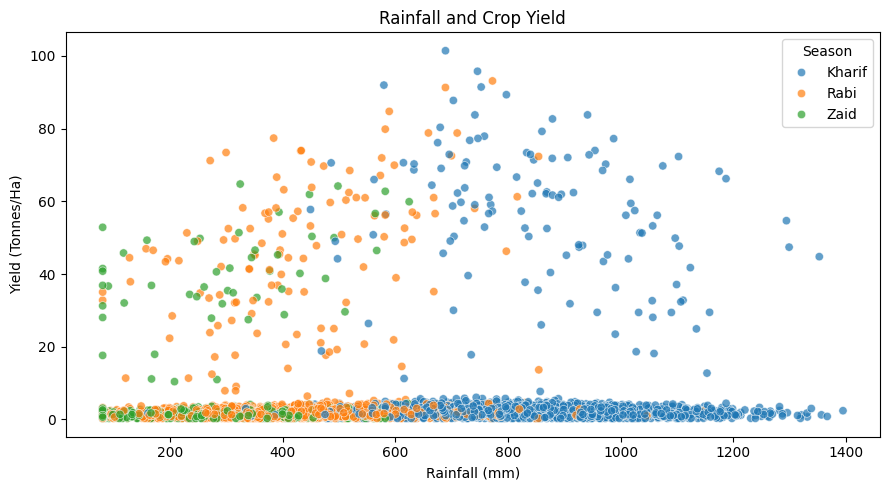

In [ ]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.7
)

plt.title("Rainfall and Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

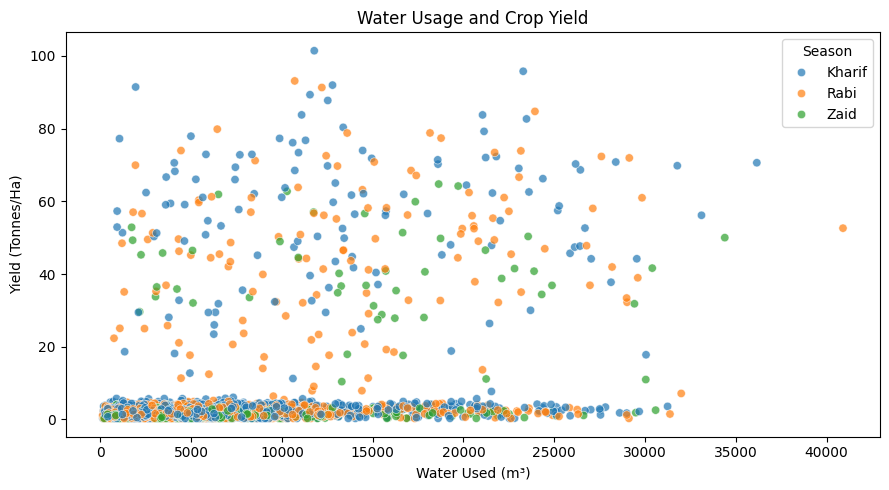

In [ ]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="Water_Used_m3",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.7
)

plt.title("Water Usage and Crop Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

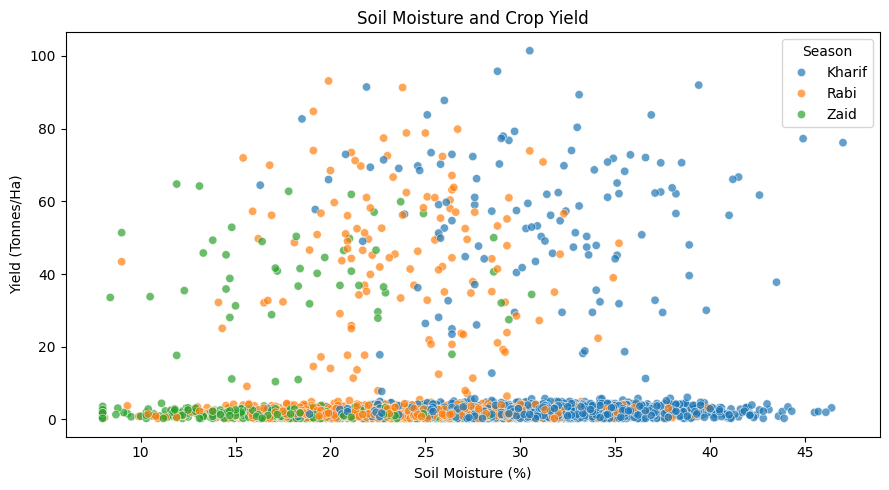

In [ ]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="Soil_Moisture_pct",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.7
)

plt.title("Soil Moisture and Crop Yield")
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

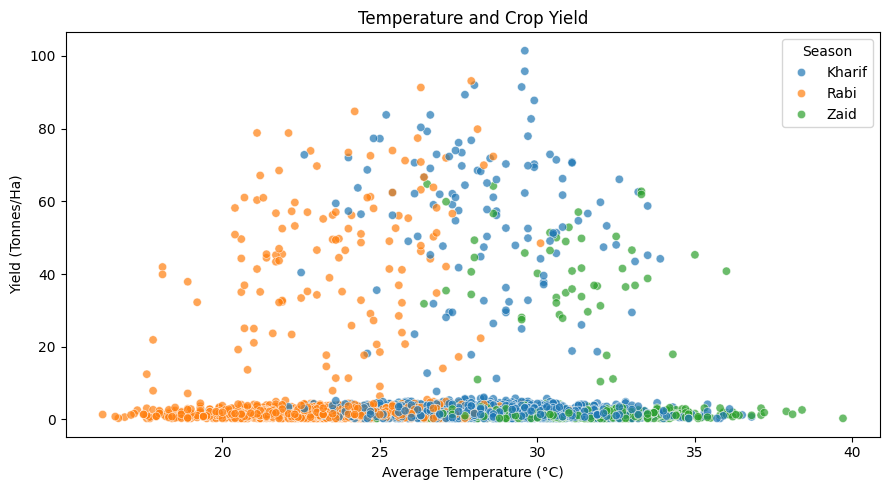

In [ ]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.7
)

plt.title("Temperature and Crop Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

In [ ]:
# ## Correlation Analysis

# Correlation analysis is used to identify the strength and direction of
# relationships between agricultural variables.

# Spearman correlation is used because it measures monotonic relationships
# and is less sensitive to non-normal distributions and extreme values than
# Pearson correlation.

In [ ]:
# Select variables relevant to agricultural performance

correlation_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct",
    "Profit_per_Hectare_INR"
]

correlation_matrix = df[correlation_columns].corr(
    method="spearman"
)

correlation_matrix.round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_per_Hectare_INR
Rainfall_mm,1.00,0.22,0.54,-0.37,0.02,0.53,0.00,0.01,0.02,0.02,0.01,-0.02,0.13,0.00,0.11,0.63,0.15
Avg_Temperature_C,0.22,1.00,0.17,-0.05,0.03,0.12,0.02,-0.00,0.02,0.01,0.01,-0.04,0.00,0.03,-0.00,0.26,0.00
Humidity_pct,0.54,0.17,1.00,-0.30,0.03,0.46,0.00,-0.01,-0.01,0.03,-0.00,-0.05,0.08,-0.00,0.06,0.55,0.09
Sunlight_Hours_Day,-0.37,-0.05,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,-0.01,-0.03,0.02,-0.05,0.00,-0.04,-0.25,-0.06
Soil_pH,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.01,-0.02,-0.01,-0.01,-0.01,-0.03,-0.02,-0.00,0.03,-0.01
Soil_Moisture_pct,0.53,0.12,0.46,-0.30,0.03,1.00,0.00,0.01,0.01,0.01,-0.02,-0.02,0.10,-0.01,0.09,0.39,0.12
Nitrogen_kg_ha,0.00,0.02,0.00,0.01,0.01,0.00,1.00,0.01,0.01,-0.03,0.02,0.01,0.08,0.02,0.07,-0.01,0.08
Phosphorus_kg_ha,0.01,-0.00,-0.01,0.00,0.01,0.01,0.01,1.00,0.00,0.01,-0.03,-0.01,0.05,-0.00,0.05,0.02,0.07
Potassium_kg_ha,0.02,0.02,-0.01,-0.01,-0.02,0.01,0.01,0.00,1.00,0.01,-0.01,0.00,0.03,0.01,0.01,0.01,0.02
Fertilizer_kg_ha,0.02,0.01,0.03,-0.01,-0.01,0.01,-0.03,0.01,0.01,1.00,0.00,0.01,0.00,0.01,0.00,0.01,-0.11


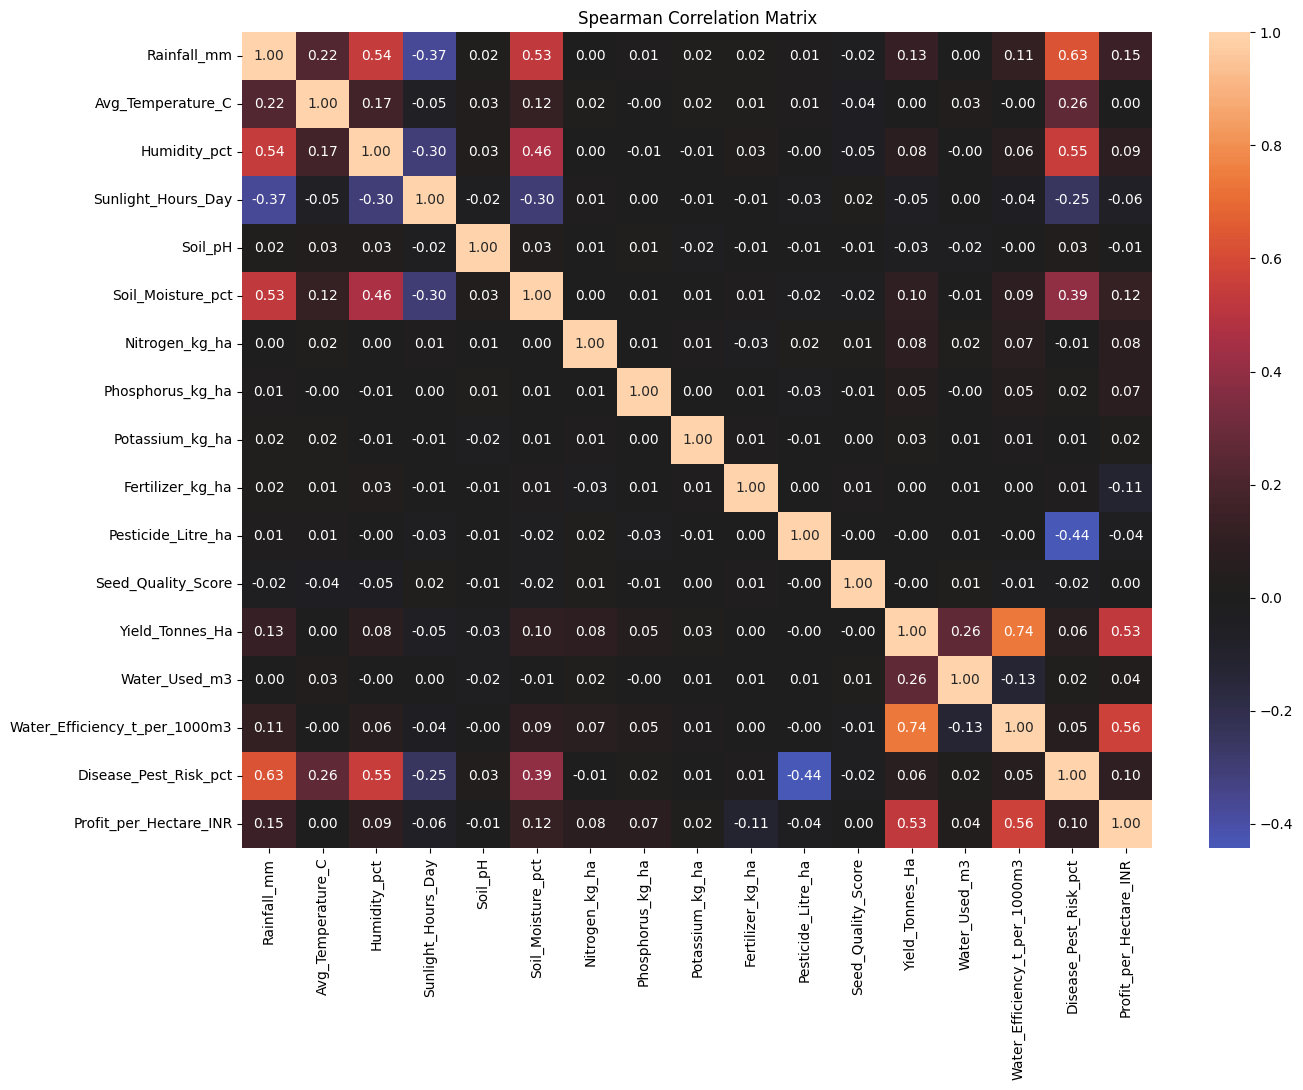

In [ ]:
plt.figure(figsize=(14, 11))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
yield_correlations = (
    correlation_matrix["Yield_Tonnes_Ha"]
    .drop("Yield_Tonnes_Ha")
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False
    )
)

yield_correlations.round(3)

Water_Efficiency_t_per_1000m3    0.74
Profit_per_Hectare_INR           0.53
Water_Used_m3                    0.26
Rainfall_mm                      0.13
Soil_Moisture_pct                0.10
Nitrogen_kg_ha                   0.08
Humidity_pct                     0.08
Disease_Pest_Risk_pct            0.07
Sunlight_Hours_Day              -0.05
Phosphorus_kg_ha                 0.05
Soil_pH                         -0.03
Potassium_kg_ha                  0.03
Fertilizer_kg_ha                 0.00
Avg_Temperature_C                0.00
Pesticide_Litre_ha              -0.00
Seed_Quality_Score              -0.00
Name: Yield_Tonnes_Ha, dtype: float64

In [ ]:
profit_correlations = (
    correlation_matrix["Profit_per_Hectare_INR"]
    .drop("Profit_per_Hectare_INR")
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False
    )
)

profit_correlations.round(3)

Water_Efficiency_t_per_1000m3    0.56
Yield_Tonnes_Ha                  0.53
Rainfall_mm                      0.15
Soil_Moisture_pct                0.12
Fertilizer_kg_ha                -0.11
Disease_Pest_Risk_pct            0.10
Humidity_pct                     0.09
Nitrogen_kg_ha                   0.08
Phosphorus_kg_ha                 0.07
Sunlight_Hours_Day              -0.06
Water_Used_m3                    0.04
Pesticide_Litre_ha              -0.04
Potassium_kg_ha                  0.02
Soil_pH                         -0.01
Avg_Temperature_C                0.00
Seed_Quality_Score               0.00
Name: Profit_per_Hectare_INR, dtype: float64

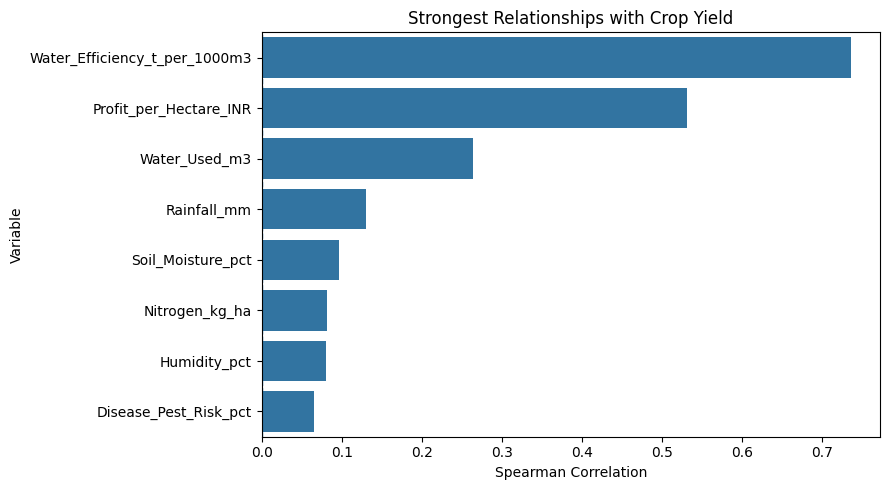

In [ ]:
top_yield_relationships = yield_correlations.head(8)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=top_yield_relationships.values,
    y=top_yield_relationships.index
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.title("Strongest Relationships with Crop Yield")
plt.xlabel("Spearman Correlation")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

In [ ]:
# ## Statistical Analysis

# Visual differences between groups do not necessarily imply that the
# differences are statistically significant.

# A Kruskal-Wallis test is used to determine whether the distribution of
# profit per hectare differs significantly across the three seasons.

# The significance level is set at 5% (α = 0.05).

In [ ]:
season_groups = [
    group["Profit_per_Hectare_INR"].values
    for _, group in df.groupby("Season")
]

kruskal_statistic, p_value = stats.kruskal(
    *season_groups
)

print("Kruskal-Wallis statistic:", round(kruskal_statistic, 4))
print("p-value:", p_value)

Kruskal-Wallis statistic: 97.1289
p-value: 8.104553466457251e-22


In [ ]:
alpha = 0.05

if p_value < alpha:
    print(
        "Conclusion: There is a statistically significant difference "
        "in profit per hectare across seasons (p < 0.05)."
    )
else:
    print(
        "Conclusion: There is no statistically significant difference "
        "in profit per hectare across seasons (p >= 0.05)."
    )

Conclusion: There is a statistically significant difference in profit per hectare across seasons (p < 0.05).


In [ ]:
season_names = df["Season"].unique()

pairwise_results = []

for i in range(len(season_names)):
    for j in range(i + 1, len(season_names)):

        season_a = season_names[i]
        season_b = season_names[j]

        values_a = df.loc[
            df["Season"] == season_a,
            "Profit_per_Hectare_INR"
        ]

        values_b = df.loc[
            df["Season"] == season_b,
            "Profit_per_Hectare_INR"
        ]

        statistic, pair_p = stats.mannwhitneyu(
            values_a,
            values_b,
            alternative="two-sided"
        )

        pairwise_results.append({
            "Season A": season_a,
            "Season B": season_b,
            "U Statistic": statistic,
            "p-value": pair_p
        })

pairwise_results = pd.DataFrame(pairwise_results)

pairwise_results

,Season A,Season B,U Statistic,p-value
0,Kharif,Rabi,"1,608,691.00",0.00
1,Kharif,Zaid,"663,232.00",0.00
2,Rabi,Zaid,"560,575.00",0.00


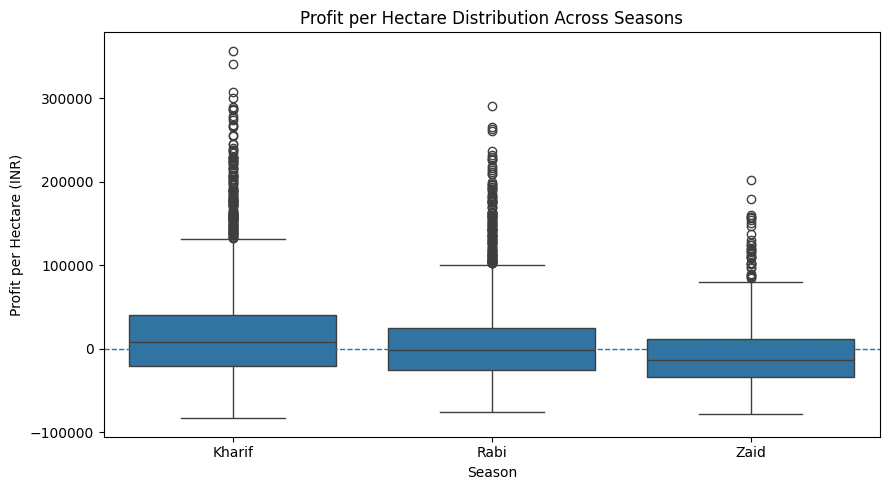

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Profit_per_Hectare_INR"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("Profit per Hectare Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit per Hectare (INR)")

plt.tight_layout()
plt.show()

In [ ]:
# ## Outlier Investigation

# Extreme observations are investigated using the Interquartile Range (IQR)
# method.

# Outliers are not automatically removed because an extreme agricultural
# observation may represent a genuine difference in crop, farm size,
# production or environmental conditions.

In [ ]:
def find_iqr_outliers(data, column):

    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)

    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outliers = data[
        (data[column] < lower_limit) |
        (data[column] > upper_limit)
    ]

    return {
        "Variable": column,
        "Q1": q1,
        "Q3": q3,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit,
        "Outlier Count": len(outliers),
        "Outlier %": (len(outliers) / len(data)) * 100
    }

In [ ]:
outlier_variables = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Water_Used_m3",
    "Profit_per_Hectare_INR"
]

outlier_summary = pd.DataFrame(
    [
        find_iqr_outliers(df, column)
        for column in outlier_variables
    ]
)

outlier_summary.round(2)

,Variable,Q1,Q3,Lower Limit,Upper Limit,Outlier Count,Outlier %
0,Yield_Tonnes_Ha,1.05,2.83,-1.62,5.50,302,7.55
1,Production_Tonnes,5.02,24.36,-23.98,53.36,333,8.33
2,Water_Used_m3,"2,268.75","7,829.75","-6,072.75","16,171.25",276,6.90
3,Profit_per_Hectare_INR,"-25,353.73","31,262.42","-110,277.96","116,186.65",284,7.10


In [ ]:
yield_q1 = df["Yield_Tonnes_Ha"].quantile(0.25)
yield_q3 = df["Yield_Tonnes_Ha"].quantile(0.75)

yield_iqr = yield_q3 - yield_q1

yield_upper_limit = yield_q3 + 1.5 * yield_iqr

high_yield_farms = df[
    df["Yield_Tonnes_Ha"] > yield_upper_limit
].sort_values(
    "Yield_Tonnes_Ha",
    ascending=False
)

high_yield_farms[
    [
        "Farm_ID",
        "State",
        "District",
        "Crop",
        "Season",
        "Farm_Area_Hectares",
        "Yield_Tonnes_Ha",
        "Water_Used_m3",
        "Irrigation_Method",
        "Profit_INR"
    ]
].head(10)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Yield_Tonnes_Ha,Water_Used_m3,Irrigation_Method,Profit_INR
1715,SF11716,Gujarat,Indore,Sugarcane,Kharif,6.32,101.44,11781,Drip,1608291
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,14.87,95.79,23289,Drip,3330582
3525,SF13526,Andhra Pradesh,Erode,Sugarcane,Rabi,6.96,93.13,10705,Drip,1471529
1464,SF11465,Gujarat,Nashik,Sugarcane,Kharif,7.65,91.98,12787,Drip,2216708
3523,SF13524,Karnataka,Nashik,Sugarcane,Kharif,0.82,91.46,1944,Flood,234320
2782,SF12783,Gujarat,Nalgonda,Sugarcane,Rabi,5.72,91.32,12199,Flood,1236801
644,SF10645,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,7.48,89.34,11547,Drip,1984818
2847,SF12848,Telangana,Warangal,Sugarcane,Kharif,7.66,87.76,12526,Drip,2041678
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,14.74,84.75,23936,Sprinkler,3378879
1178,SF11179,Karnataka,Nalgonda,Sugarcane,Kharif,6.38,83.79,11086,Drip,1200815


In [ ]:
high_yield_crop_distribution = (
    high_yield_farms["Crop"]
    .value_counts()
)

high_yield_crop_distribution

Crop
Sugarcane    293
Maize          7
Rice           2
Name: count, dtype: int64

In [ ]:
high_yield_season_distribution = (
    high_yield_farms["Season"]
    .value_counts()
)

high_yield_season_distribution

Season
Kharif    129
Rabi      124
Zaid       49
Name: count, dtype: int64

In [ ]:
final_season_ranking = season_summary[
    [
        "Average_Yield_Tonnes_Ha",
        "Average_Profit_per_Hectare_INR",
        "Average_Water_Used_m3",
        "Average_Water_Efficiency",
        "Average_Disease_Risk_pct"
    ]
].copy()

final_season_ranking

,Average_Yield_Tonnes_Ha,Average_Profit_per_Hectare_INR,Average_Water_Used_m3,Average_Water_Efficiency,Average_Disease_Risk_pct
Season,,,,,
Kharif,5.63,"21,881.81","6,102.20",5.89,54.47
Rabi,5.04,"10,361.68","5,846.99",5.19,40.48
Zaid,4.64,"-2,636.52","6,419.89",4.41,38.22


In [ ]:
season_summary.to_csv(
    "../outputs/tables/season_summary.csv"
)

crop_summary.to_csv(
    "../outputs/tables/crop_summary.csv"
)

irrigation_summary.to_csv(
    "../outputs/tables/irrigation_summary.csv"
)

correlation_matrix.to_csv(
    "../outputs/tables/correlation_matrix.csv"
)

pairwise_results.to_csv(
    "../outputs/tables/season_pairwise_tests.csv",
    index=False
)

print("Analysis tables saved successfully.")

Analysis tables saved successfully.


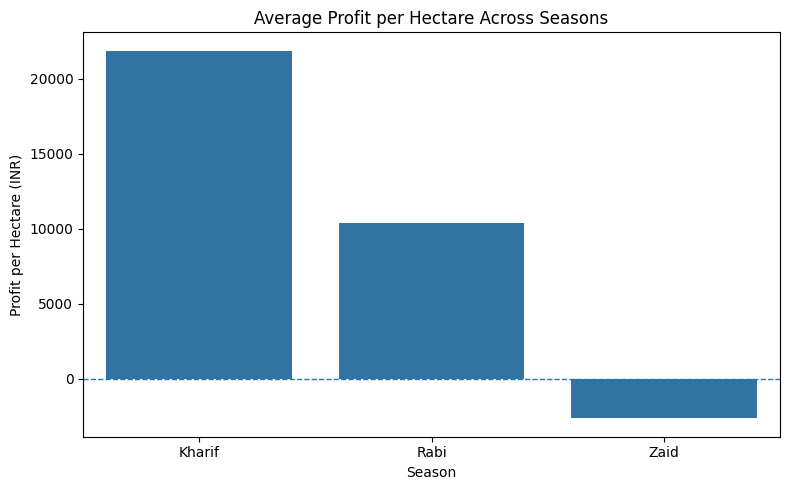

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_per_Hectare_INR",
    estimator="mean",
    errorbar=None
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("Average Profit per Hectare Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit per Hectare (INR)")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/season_profit_per_hectare.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ## Correlation Analysis

# Correlation analysis is used to investigate relationships between agricultural
# conditions, resource usage, crop yield and economic performance.

# Spearman correlation is used because it measures monotonic relationships and
# does not require the variables to follow a normal distribution.

In [ ]:
correlation_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct",
    "Profit_per_Hectare_INR"
]

correlation_matrix = df[correlation_columns].corr(
    method="spearman"
)

correlation_matrix.round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_per_Hectare_INR
Rainfall_mm,1.00,0.22,0.54,-0.37,0.02,0.53,0.00,0.01,0.02,0.02,0.01,-0.02,0.13,0.00,0.11,0.63,0.15
Avg_Temperature_C,0.22,1.00,0.17,-0.05,0.03,0.12,0.02,-0.00,0.02,0.01,0.01,-0.04,0.00,0.03,-0.00,0.26,0.00
Humidity_pct,0.54,0.17,1.00,-0.30,0.03,0.46,0.00,-0.01,-0.01,0.03,-0.00,-0.05,0.08,-0.00,0.06,0.55,0.09
Sunlight_Hours_Day,-0.37,-0.05,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,-0.01,-0.03,0.02,-0.05,0.00,-0.04,-0.25,-0.06
Soil_pH,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.01,-0.02,-0.01,-0.01,-0.01,-0.03,-0.02,-0.00,0.03,-0.01
Soil_Moisture_pct,0.53,0.12,0.46,-0.30,0.03,1.00,0.00,0.01,0.01,0.01,-0.02,-0.02,0.10,-0.01,0.09,0.39,0.12
Nitrogen_kg_ha,0.00,0.02,0.00,0.01,0.01,0.00,1.00,0.01,0.01,-0.03,0.02,0.01,0.08,0.02,0.07,-0.01,0.08
Phosphorus_kg_ha,0.01,-0.00,-0.01,0.00,0.01,0.01,0.01,1.00,0.00,0.01,-0.03,-0.01,0.05,-0.00,0.05,0.02,0.07
Potassium_kg_ha,0.02,0.02,-0.01,-0.01,-0.02,0.01,0.01,0.00,1.00,0.01,-0.01,0.00,0.03,0.01,0.01,0.01,0.02
Fertilizer_kg_ha,0.02,0.01,0.03,-0.01,-0.01,0.01,-0.03,0.01,0.01,1.00,0.00,0.01,0.00,0.01,0.00,0.01,-0.11


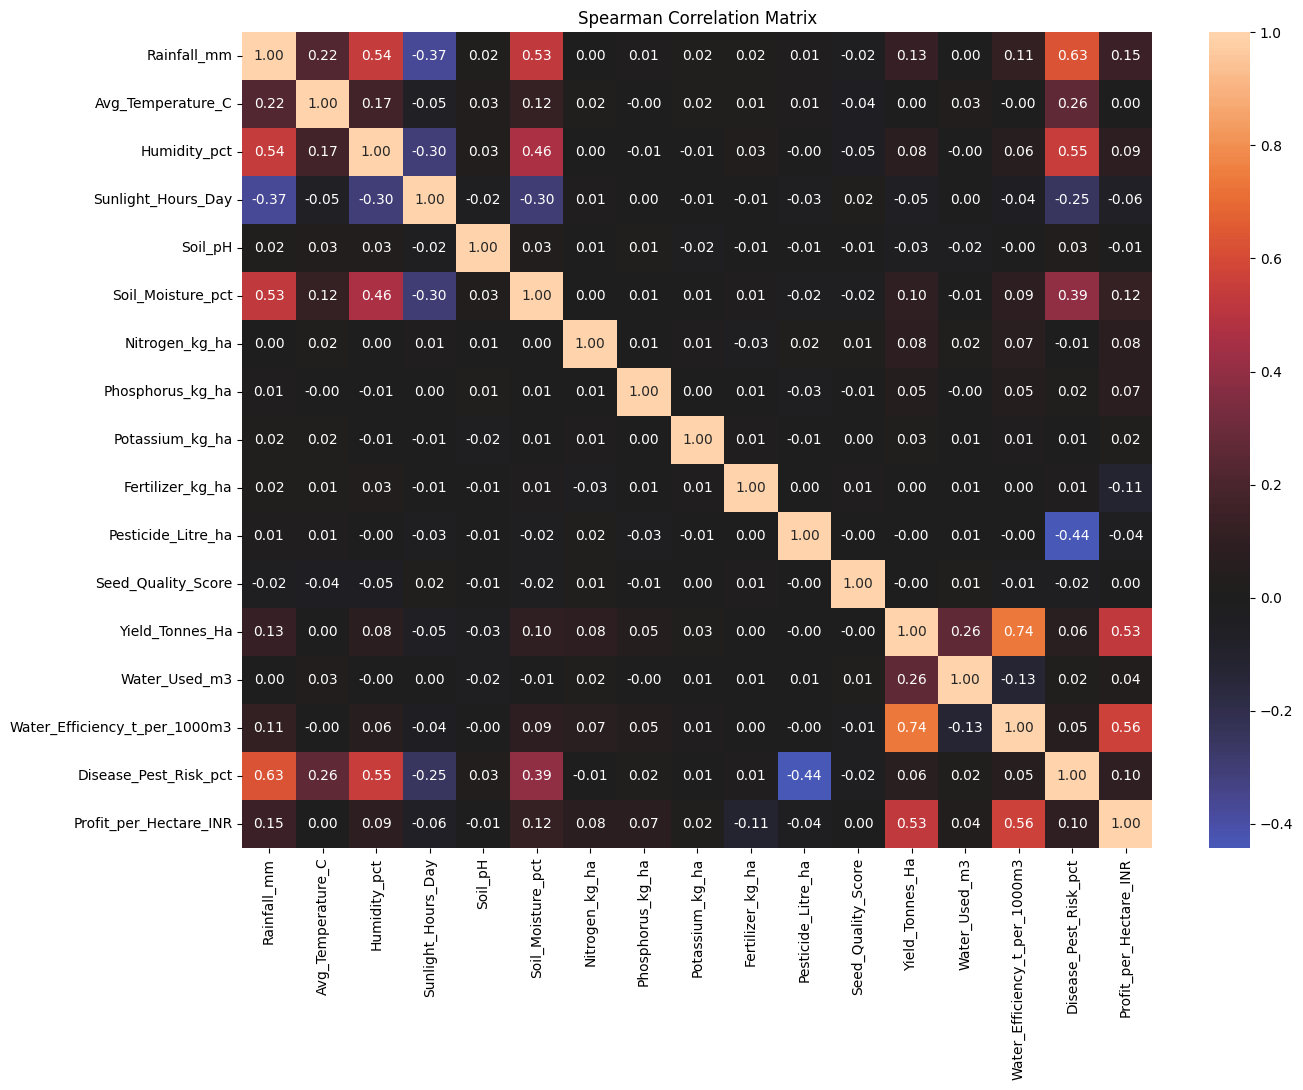

In [ ]:
plt.figure(figsize=(14, 11))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
yield_correlations = (
    correlation_matrix["Yield_Tonnes_Ha"]
    .drop("Yield_Tonnes_Ha")
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

yield_correlations.round(3)

Water_Efficiency_t_per_1000m3    0.74
Profit_per_Hectare_INR           0.53
Water_Used_m3                    0.26
Rainfall_mm                      0.13
Soil_Moisture_pct                0.10
Nitrogen_kg_ha                   0.08
Humidity_pct                     0.08
Disease_Pest_Risk_pct            0.07
Sunlight_Hours_Day              -0.05
Phosphorus_kg_ha                 0.05
Soil_pH                         -0.03
Potassium_kg_ha                  0.03
Fertilizer_kg_ha                 0.00
Avg_Temperature_C                0.00
Pesticide_Litre_ha              -0.00
Seed_Quality_Score              -0.00
Name: Yield_Tonnes_Ha, dtype: float64

In [ ]:
profit_correlations = (
    correlation_matrix["Profit_per_Hectare_INR"]
    .drop("Profit_per_Hectare_INR")
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

profit_correlations.round(3)

Water_Efficiency_t_per_1000m3    0.56
Yield_Tonnes_Ha                  0.53
Rainfall_mm                      0.15
Soil_Moisture_pct                0.12
Fertilizer_kg_ha                -0.11
Disease_Pest_Risk_pct            0.10
Humidity_pct                     0.09
Nitrogen_kg_ha                   0.08
Phosphorus_kg_ha                 0.07
Sunlight_Hours_Day              -0.06
Water_Used_m3                    0.04
Pesticide_Litre_ha              -0.04
Potassium_kg_ha                  0.02
Soil_pH                         -0.01
Avg_Temperature_C                0.00
Seed_Quality_Score               0.00
Name: Profit_per_Hectare_INR, dtype: float64

In [ ]:
# ## Statistical Testing

# The visual analysis indicates differences in profitability across seasons.
# A statistical test is therefore used to determine whether the observed
# seasonal differences are statistically significant.

# The Kruskal-Wallis test is used because profit per hectare may not follow
# a normal distribution.

In [ ]:
season_groups = [
    group["Profit_per_Hectare_INR"].values
    for _, group in df.groupby("Season")
]

kruskal_statistic, p_value = stats.kruskal(
    *season_groups
)

print("Kruskal-Wallis statistic:", round(kruskal_statistic, 4))
print("p-value:", p_value)

Kruskal-Wallis statistic: 97.1289
p-value: 8.104553466457251e-22


In [ ]:
alpha = 0.05

print("Significance level:", alpha)

if p_value < alpha:
    print(
        "\nResult: The difference in profit per hectare "
        "across seasons is statistically significant."
    )
else:
    print(
        "\nResult: The difference in profit per hectare "
        "across seasons is not statistically significant."
    )

Significance level: 0.05

Result: The difference in profit per hectare across seasons is statistically significant.


In [ ]:
season_names = sorted(df["Season"].unique())

pairwise_results = []

for i in range(len(season_names)):
    for j in range(i + 1, len(season_names)):

        season_a = season_names[i]
        season_b = season_names[j]

        values_a = df.loc[
            df["Season"] == season_a,
            "Profit_per_Hectare_INR"
        ]

        values_b = df.loc[
            df["Season"] == season_b,
            "Profit_per_Hectare_INR"
        ]

        statistic, pair_p = stats.mannwhitneyu(
            values_a,
            values_b,
            alternative="two-sided"
        )

        pairwise_results.append({
            "Season A": season_a,
            "Season B": season_b,
            "U Statistic": statistic,
            "p-value": pair_p
        })

pairwise_results = pd.DataFrame(pairwise_results)

pairwise_results

,Season A,Season B,U Statistic,p-value
0,Kharif,Rabi,"1,608,691.00",0.00
1,Kharif,Zaid,"663,232.00",0.00
2,Rabi,Zaid,"560,575.00",0.00


In [ ]:
pairwise_results["Significant_at_5pct"] = (
    pairwise_results["p-value"] < 0.05
)

pairwise_results

,Season A,Season B,U Statistic,p-value,Significant_at_5pct
0,Kharif,Rabi,"1,608,691.00",0.00,True
1,Kharif,Zaid,"663,232.00",0.00,True
2,Rabi,Zaid,"560,575.00",0.00,True


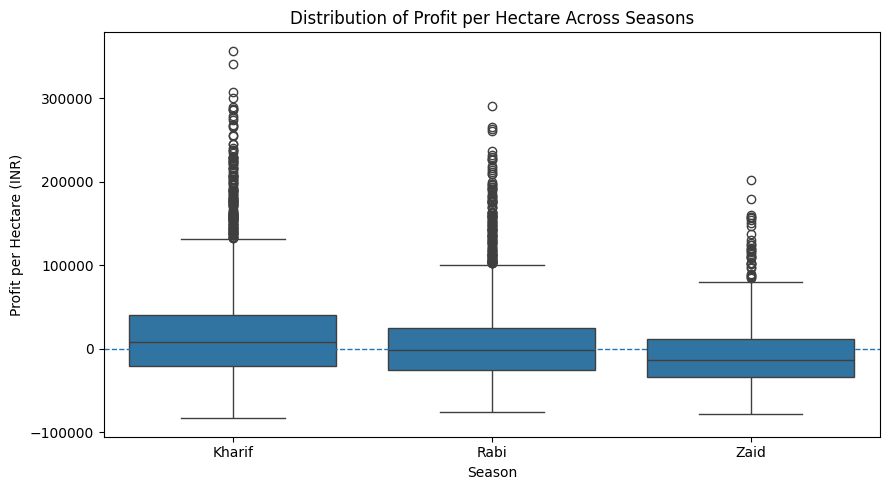

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Profit_per_Hectare_INR"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("Distribution of Profit per Hectare Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit per Hectare (INR)")

plt.tight_layout()
plt.show()

In [ ]:
zaid_summary = df[df["Season"] == "Zaid"].agg({
    "Yield_Tonnes_Ha": "mean",
    "Profit_per_Hectare_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Fertilizer_kg_ha": "mean",
    "Pesticide_Litre_ha": "mean",
    "Disease_Pest_Risk_pct": "mean",
    "Total_Cost_INR": "mean",
    "Revenue_INR": "mean"
})

zaid_summary

Yield_Tonnes_Ha                       4.64
Profit_per_Hectare_INR           -2,636.52
Water_Used_m3                     6,419.89
Water_Efficiency_t_per_1000m3         4.41
Fertilizer_kg_ha                    184.64
Pesticide_Litre_ha                    5.17
Disease_Pest_Risk_pct                38.22
Total_Cost_INR                  543,976.73
Revenue_INR                     519,171.90
dtype: float64

In [ ]:
season_resource_comparison = df.groupby("Season").agg(
    Yield=("Yield_Tonnes_Ha", "mean"),
    Profit_per_Hectare=("Profit_per_Hectare_INR", "mean"),
    Water_Used=("Water_Used_m3", "mean"),
    Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Fertilizer=("Fertilizer_kg_ha", "mean"),
    Pesticide=("Pesticide_Litre_ha", "mean"),
    Disease_Risk=("Disease_Pest_Risk_pct", "mean"),
    Total_Cost=("Total_Cost_INR", "mean"),
    Revenue=("Revenue_INR", "mean")
).round(2)

season_resource_comparison

,Yield,Profit_per_Hectare,Water_Used,Water_Efficiency,Fertilizer,Pesticide,Disease_Risk,Total_Cost,Revenue
Season,,,,,,,,,
Kharif,5.63,"21,881.81","6,102.20",5.89,187.08,5.08,54.47,"531,804.41","710,719.06"
Rabi,5.04,"10,361.68","5,846.99",5.19,185.41,5.02,40.48,"513,836.58","601,526.05"
Zaid,4.64,"-2,636.52","6,419.89",4.41,184.64,5.17,38.22,"543,976.73","519,171.90"


In [ ]:
economic_comparison = df.groupby("Season").agg(
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Total_Cost=("Total_Cost_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Revenue_per_Hectare=("Revenue_per_Hectare_INR", "mean"),
    Average_Cost_per_Hectare=("Cost_per_Hectare_INR", "mean"),
    Average_Profit_per_Hectare=("Profit_per_Hectare_INR", "mean")
).round(2)

economic_comparison

,Average_Revenue,Average_Total_Cost,Average_Profit,Average_Revenue_per_Hectare,Average_Cost_per_Hectare,Average_Profit_per_Hectare
Season,,,,,,
Kharif,"710,719.06","531,804.41","178,914.65","88,782.79","66,900.98","21,881.81"
Rabi,"601,526.05","513,836.58","87,689.47","76,656.92","66,295.24","10,361.68"
Zaid,"519,171.90","543,976.73","-24,804.82","64,301.42","66,937.94","-2,636.52"


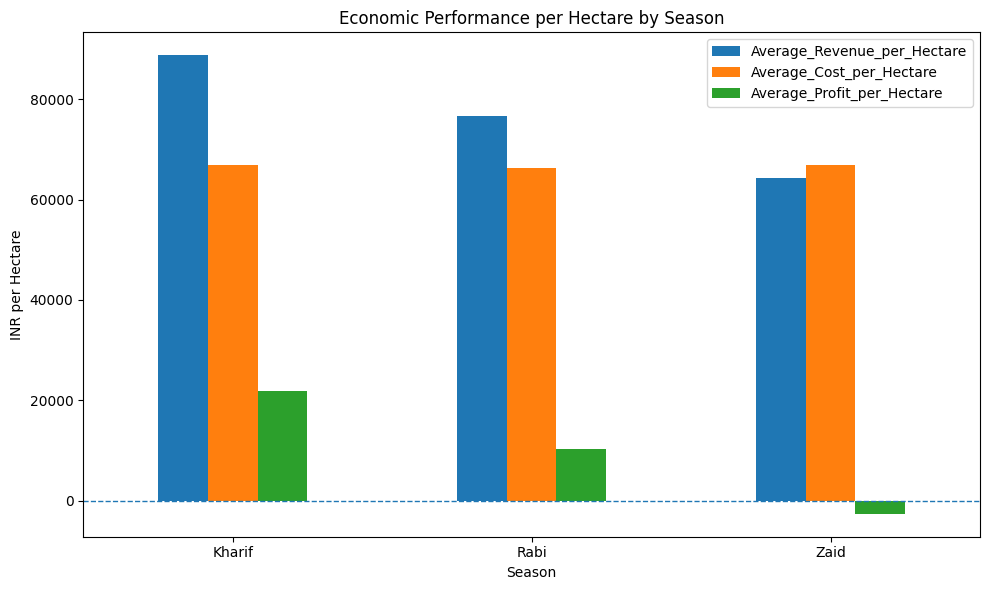

In [ ]:
economic_plot = economic_comparison[
    [
        "Average_Revenue_per_Hectare",
        "Average_Cost_per_Hectare",
        "Average_Profit_per_Hectare"
    ]
]

economic_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("Economic Performance per Hectare by Season")
plt.xlabel("Season")
plt.ylabel("INR per Hectare")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
irrigation_season_profit = df.pivot_table(
    values="Profit_per_Hectare_INR",
    index="Irrigation_Method",
    columns="Season",
    aggfunc="mean"
)

irrigation_season_profit.round(2)

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,"36,258.64","22,675.71","2,539.64"
Flood,"16,606.88","6,809.23","-8,936.95"
Rainfed,"18,086.67","6,450.40","-9,497.57"
Sprinkler,"18,912.17","7,035.86","9,514.87"


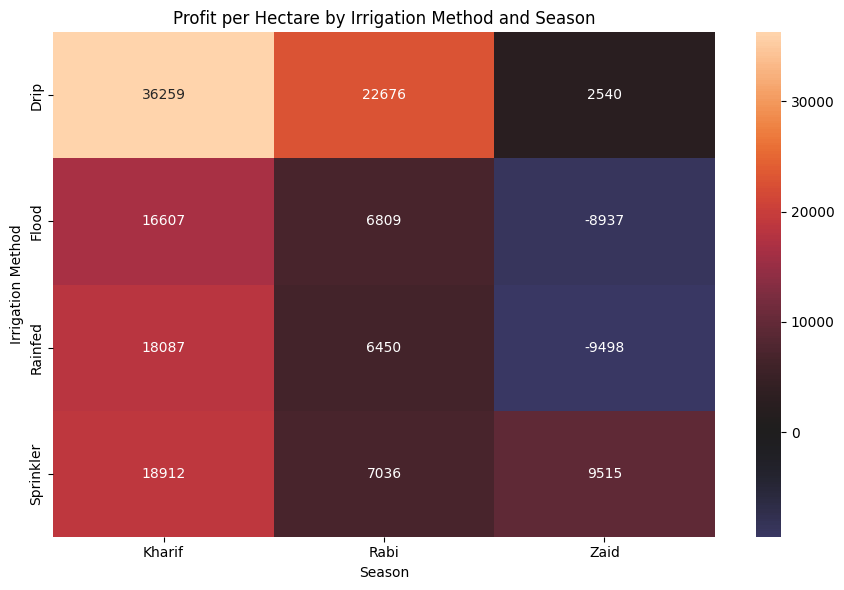

In [ ]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    irrigation_season_profit,
    annot=True,
    fmt=".0f",
    center=0
)

plt.title("Profit per Hectare by Irrigation Method and Season")
plt.xlabel("Season")
plt.ylabel("Irrigation Method")

plt.tight_layout()
plt.show()

In [ ]:
crop_season_results = (
    df.groupby(["Crop", "Season"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit_per_Hectare=(
            "Profit_per_Hectare_INR",
            "mean"
        ),
        Number_of_Farms=("Farm_ID", "count")
    )
    .reset_index()
)

crop_season_results = crop_season_results.sort_values(
    "Average_Profit_per_Hectare",
    ascending=False
)

crop_season_results.head(10)

,Crop,Season,Average_Yield,Average_Profit_per_Hectare,Number_of_Farms
18,Sugarcane,Kharif,53.46,"120,564.29",125
0,Chilli,Kharif,1.73,"111,812.03",185
19,Sugarcane,Rabi,43.29,"86,013.50",129
1,Chilli,Rabi,1.47,"85,696.18",163
20,Sugarcane,Zaid,38.42,"68,049.98",51
2,Chilli,Zaid,1.20,"51,578.32",64
3,Cotton,Kharif,1.37,"27,343.10",215
6,Groundnut,Kharif,1.48,"16,870.94",193
4,Cotton,Rabi,1.20,"13,517.73",201
12,Pulses,Kharif,1.04,"7,043.55",221


In [ ]:
crop_season_results.tail(10)

,Crop,Season,Average_Yield,Average_Profit_per_Hectare,Number_of_Farms
15,Rice,Kharif,2.70,"-7,986.98",314
8,Groundnut,Zaid,1.04,"-8,168.15",54
10,Maize,Rabi,2.60,"-11,776.24",233
21,Wheat,Kharif,2.25,"-13,181.57",292
16,Rice,Rabi,2.32,"-14,524.71",274
22,Wheat,Rabi,2.06,"-16,083.98",237
14,Pulses,Zaid,0.67,"-18,905.27",62
11,Maize,Zaid,2.29,"-20,422.12",84
23,Wheat,Zaid,1.75,"-25,222.79",85
17,Rice,Zaid,1.90,"-25,266.34",102


In [ ]:
season_crop_percentage = pd.crosstab(
    df["Season"],
    df["Crop"],
    normalize="index"
) * 100

season_crop_percentage.round(2)

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,10.40,12.09,10.85,13.15,12.42,17.65,7.03,16.41
Rabi,10.02,12.35,10.88,14.32,13.09,16.84,7.93,14.57
Zaid,10.77,15.49,9.09,14.14,10.44,17.17,8.59,14.31


In [ ]:
season_summary.to_csv(
    "../outputs/tables/season_summary.csv"
)

crop_summary.to_csv(
    "../outputs/tables/crop_summary.csv"
)

irrigation_summary.to_csv(
    "../outputs/tables/irrigation_summary.csv"
)

correlation_matrix.to_csv(
    "../outputs/tables/correlation_matrix.csv"
)

pairwise_results.to_csv(
    "../outputs/tables/season_pairwise_tests.csv",
    index=False
)

economic_comparison.to_csv(
    "../outputs/tables/economic_comparison.csv"
)

crop_season_results.to_csv(
    "../outputs/tables/crop_season_results.csv",
    index=False
)

print("Final analysis tables saved successfully.")

Final analysis tables saved successfully.


In [ ]:
best_yield_season = season_summary[
    "Average_Yield_Tonnes_Ha"
].idxmax()

best_profit_season = season_summary[
    "Average_Profit_per_Hectare_INR"
].idxmax()

highest_water_use = season_summary[
    "Average_Water_Used_m3"
].idxmax()

best_water_efficiency = season_summary[
    "Average_Water_Efficiency"
].idxmax()

best_irrigation = irrigation_summary[
    "Average_Profit_per_Hectare_INR"
].idxmax()

best_crop = crop_summary[
    "Average_Profit_per_Hectare_INR"
].idxmax()

print("FINAL ANALYTICAL HIGHLIGHTS")
print("=" * 50)

print(f"Highest average yield season       : {best_yield_season}")
print(f"Highest average profit/ha season   : {best_profit_season}")
print(f"Highest average water usage season : {highest_water_use}")
print(f"Highest water efficiency season    : {best_water_efficiency}")
print(f"Highest profit/ha irrigation       : {best_irrigation}")
print(f"Highest profit/ha crop             : {best_crop}")

FINAL ANALYTICAL HIGHLIGHTS
Highest average yield season       : Kharif
Highest average profit/ha season   : Kharif
Highest average water usage season : Zaid
Highest water efficiency season    : Kharif
Highest profit/ha irrigation       : Drip
Highest profit/ha crop             : Sugarcane


In [ ]:
final_findings = pd.DataFrame({
    "Analysis": [
        "Season with highest yield",
        "Season with highest profit/ha",
        "Season with highest water usage",
        "Season with highest water efficiency",
        "Most profitable irrigation method",
        "Most profitable crop"
    ],
    "Result": [
        best_yield_season,
        best_profit_season,
        highest_water_use,
        best_water_efficiency,
        best_irrigation,
        best_crop
    ]
})

final_findings

,Analysis,Result
0,Season with highest yield,Kharif
1,Season with highest profit/ha,Kharif
2,Season with highest water usage,Zaid
3,Season with highest water efficiency,Kharif
4,Most profitable irrigation method,Drip
5,Most profitable crop,Sugarcane


In [ ]:
# # Key Findings

# The analysis identified several differences in agricultural performance
# across seasons, crops and irrigation methods.

# ## Seasonal Performance

# - Seasonal differences were observed in crop yield and economic performance.
# - Kharif recorded the strongest average economic performance in the analyzed
#   dataset.
# - Zaid showed substantially lower average profitability per hectare and
#   requires further investigation.
# - Water usage and water efficiency also varied across seasons.

# ## Crop Performance

# - Crop profitability varied considerably across crop-season combinations.
# - Comparing crop performance across seasons provides more information than
#   comparing crops using a single overall average.

# ## Resource Utilization

# - Irrigation methods showed differences in profitability and water efficiency.
# - Water usage should therefore be evaluated together with yield and economic
#   performance.

# ## Statistical Evidence

# - Statistical testing was used to determine whether observed seasonal
#   differences in profitability were significant.

# ## Overall Conclusion

# Agricultural performance is influenced by a combination of seasonal,
# environmental, crop, resource and economic factors. Therefore, seasonal
# planning should consider multiple performance indicators rather than yield
# alone.

In [ ]:
seasonal_water_efficiency_plot(df)

In [ ]:
crop_profit_plot(crop_summary(df))

In [ ]:
crop_season_heatmap(crop_season_profit(df))